In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("../Plots", exist_ok=True)

# Explorer la structure du jeu de données

In [3]:
# Télécharger le jeu de données
data = pd.read_csv("../data/vitesse_moteur_20260511_120232.csv")
data.head() # 5 premières entrées

,timestamp,duty_cycle,speed_mps
0,693,0,0.0005
1,12:02:34.694,0,0.0003
2,12:02:34.694,0,0.0002
3,12:02:34.694,0,0.0001
4,12:02:34.812,0,0.0001


In [4]:
# Nettoyage des données
data_filtered = data.groupby('duty_cycle', as_index=False)['speed_mps'].mean()

pick = round(data_filtered["speed_mps"],3) > 0
data_filtered = data_filtered[pick]

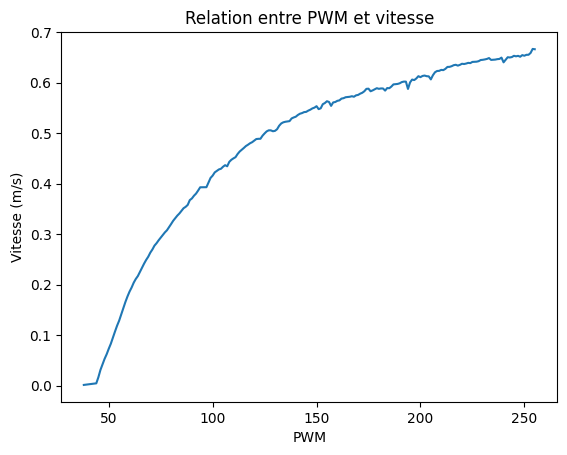

In [5]:
sns.color_palette("colorblind")

sns.lineplot(data_filtered, x="duty_cycle", y="speed_mps")
plt.xlabel("PWM")
plt.ylabel("Vitesse (m/s)")
plt.title("Relation entre PWM et vitesse")
plt.savefig("../Plots/PWM_Vitesse.pdf", format="pdf", bbox_inches="tight", dpi=300) # Sauvegarde du graphique en .pdf
plt.show()

In [6]:
# Division du jeu de données en données d'apprentissage et de validation
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(data_filtered[["speed_mps"]], data_filtered[["duty_cycle"]], test_size=0.2, random_state=42)

# Sélection et entraînement de modèles

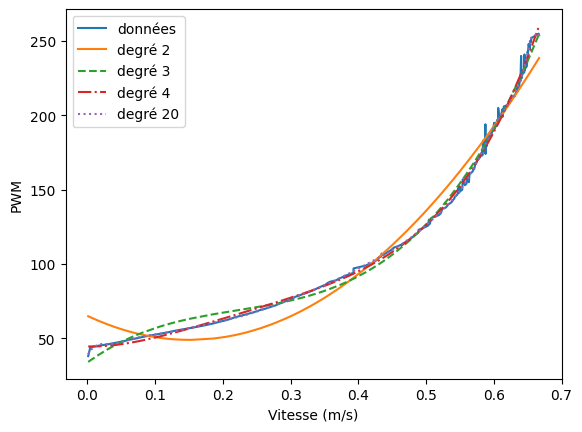

In [7]:
# Régression polynomiale à l'aide de la régression linéaire
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

degrees = [2, 3, 4, 20]
linetype_value = ["-", "--", "-.", "dotted"]
sns.lineplot(data=data_filtered, x="speed_mps", y="duty_cycle", label="données")
for degree, line in zip(degrees, linetype_value):
    poly_features = PolynomialFeatures(degree=degree, include_bias=True)
    X_poly = poly_features.fit_transform(X_train)
    lin_reg = LinearRegression()
    lin_reg.fit(X_poly, y_train)

    # Visualisation du modèle
    y_pred = lin_reg.predict(X_poly)
    sns.lineplot(x=X_train["speed_mps"], y=y_pred.ravel(), linestyle=line, label=f"degré {degree}")

plt.xlabel("Vitesse (m/s)")
plt.ylabel("PWM")
plt.legend()
plt.savefig("../Plots/Complexite.pdf", format="pdf", bbox_inches="tight", dpi=300)
plt.show()

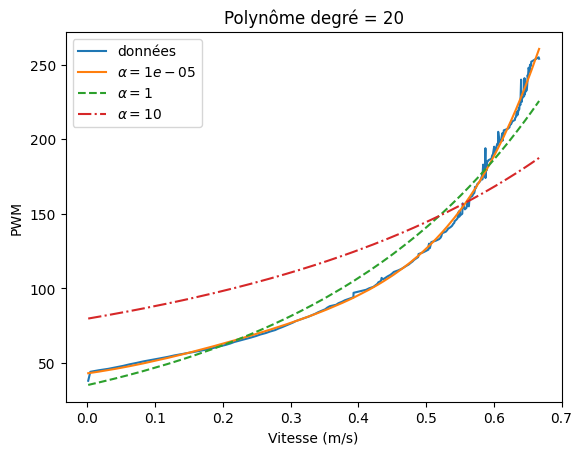

In [8]:

from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split

# Visualisation de l'effet de alpha: Régression Ridge
alphas = [1e-5, 1, 10]
degre = 20
sns.lineplot(data=data_filtered, x="speed_mps", y="duty_cycle", label="données")
for alpha, line in zip(alphas, linetype_value):
    model = make_pipeline(
        PolynomialFeatures(degree=degre, include_bias=False),
        Ridge(alpha=alpha, random_state=42)
    )
    model.fit(X_train, y_train)

    # Visualisation du modèle
    y_pred = model.predict(X_train)
    sns.lineplot(x=X_train["speed_mps"], y=y_pred.ravel(), linestyle=line, label=f"$\\alpha = {alpha}$")

plt.xlabel("Vitesse (m/s)")
plt.ylabel("PWM")
plt.title(f"Polynôme degré = {degre}")
plt.legend()
plt.savefig("../Plots/RegressionRidge_"+str(degre)+".pdf", format="pdf", bbox_inches="tight", dpi=300) # Saving the plot as .pdf
plt.show()

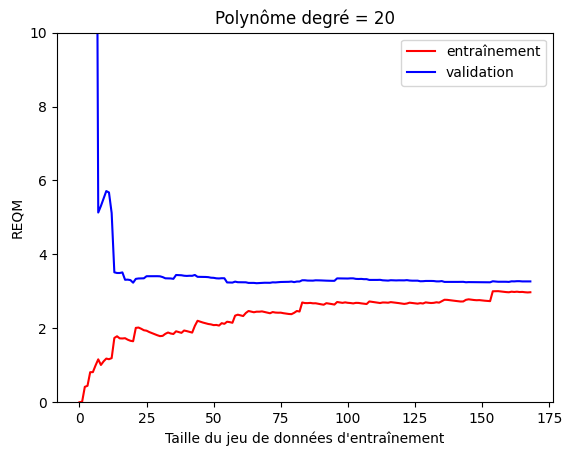

In [9]:
# Visualisation de la courbe d'apprentissage pour les données Sales vs TV
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import make_pipeline

alpha = 1e-5
degre = 20
def plot_learning_curves(X, y):
    train_errors, val_erros = [], []
    model = make_pipeline(
            PolynomialFeatures(degree=degre, include_bias=True),
            Ridge(alpha=alpha, random_state=42)
        )

    for N in range(1, len(X_train)):
        model.fit(X[:N], y[:N])

        y_train_predict = model.predict(X[:N])
        y_val_predict = model.predict(X_val)
        train_errors.append(mean_squared_error(y[:N], y_train_predict))
        val_erros.append(mean_squared_error(y_val, y_val_predict))
        
    plt.plot(np.sqrt(train_errors), "r-", label="entraînement")
    plt.plot(np.sqrt(val_erros), "b-", label="validation")
    plt.xlabel("Taille du jeu de données d'entraînement")
    plt.ylabel("REQM")
    plt.ylim(bottom=0, top=10)
    plt.title(f"Polynôme degré = {degre}")
    plt.legend()
    plt.savefig("../Plots/Surajustement_"+str(degre)+".pdf", format="pdf", bbox_inches="tight", dpi=300)

plot_learning_curves(X_train, y_train)

In [10]:
# Tuning du paramètre alpha
from sklearn.model_selection import GridSearchCV

param_grid = [
    {
        'polynomialfeatures__degree': [3],
        'ridge__alpha': [0, 1e-20, 1e-7, 1e-2, 0.1, 1, 10, 30],
        'ridge__fit_intercept': [True, False]
    }
]

model = make_pipeline(
            PolynomialFeatures(),
            Ridge()
        )
grid_search = GridSearchCV(
    model,
    param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    return_train_score=True,
    n_jobs=1
)

# Modèle évalué pour toutes les combinaisons de paramètres
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)


/media/christian/22F4BCAE291A75E1/Learning/MLenv/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=1.07812e-21): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/media/christian/22F4BCAE291A75E1/Learning/MLenv/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=1.1173e-21): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/media/christian/22F4BCAE291A75E1/Learning/MLenv/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=1.11816e-21): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/media/christian/22F4BCAE291A75E1/Learning/MLenv/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=1.14216e-21): result may not be accurate.
  

Best parameters: {'polynomialfeatures__degree': 3, 'ridge__alpha': 1e-07, 'ridge__fit_intercept': True}
Best score: -4.104736569456033


In [11]:
# Extraction des coefficients du polynôme de dégré 3
bestmodel = grid_search.best_estimator_

poly = bestmodel.named_steps['polynomialfeatures']
ridge = bestmodel.named_steps['ridge']

degremodel = poly.degree
coefficients = ridge.coef_
intercept = poly.include_bias

print(f"Degre: {degremodel}")
print(f"Coefficients: {coefficients}")
print(f"Intercept: {intercept}")

Degre: 3
Coefficients: [    0.           329.73984207 -1157.73272462  1739.81042146]
Intercept: True


# Sauvegarde des coefficients du modele dans un fichier pour Arduino

In [ ]:
with open("../arduino/main/feedforward_model.h", "w") as f:
    f.write(f"""#ifndef FEEDFORWARD_MODEL_H
#define FEEDFORWARD_MODEL_H

// Model de degre : {degremodel}
// Regression Ridge

const int POLY_DEGRE = {degremodel};

const float ff_coeffs[POLY_DEGRE + 1] = {{ 
""")
  
    for coef in coefficients:
        f.write(f"    {coef:.10f},\n")
    
    f.write("};\n\n#endif\n")
